<a href="https://colab.research.google.com/github/prasanna-venkatesh-m/Analytics-Forecast/blob/main/Branchwise_SumofTotalPAR_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBRegressor, callback
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [38]:
df = pd.read_csv('/content/lag_data.csv')

columns_to_take = [
    'Date',
    'BranchID',
    'SumofTotalPAR'
]

data_df = df[columns_to_take].copy()

In [39]:
data_df['Date'] = pd.to_datetime(data_df['Date'], dayfirst=True)

data_df = data_df.sort_values(['BranchID', 'Date'])

In [40]:
upper = data_df['SumofTotalPAR'].quantile(0.99)

data_df['SumofTotalPAR'] = np.clip(
    data_df['SumofTotalPAR'],
    None,
    upper
)

In [41]:
lags = [1,2,3,7,14,30]

for lag in lags:
    data_df[f'lag_{lag}'] = (
        data_df
        .groupby('BranchID')['SumofTotalPAR']
        .shift(lag)
    )

In [42]:
data_df['ema_7'] = (
    data_df
    .groupby('BranchID')['SumofTotalPAR']
    .transform(lambda x: x.shift(1).ewm(span=7).mean())
)

data_df['ema_14'] = (
    data_df
    .groupby('BranchID')['SumofTotalPAR']
    .transform(lambda x: x.shift(1).ewm(span=14).mean())
)

data_df['ema_30'] = (
    data_df
    .groupby('BranchID')['SumofTotalPAR']
    .transform(lambda x: x.shift(1).ewm(span=30).mean())
)

In [43]:
data_df['diff_1'] = (
    data_df
    .groupby('BranchID')['SumofTotalPAR']
    .diff(1)
)

data_df['diff_7'] = (
    data_df
    .groupby('BranchID')['SumofTotalPAR']
    .diff(7)
)

data_df['pct_change_1'] = (
    data_df
    .groupby('BranchID')['SumofTotalPAR']
    .pct_change(1)
)

In [44]:
data_df['day'] = data_df['Date'].dt.day
data_df['month'] = data_df['Date'].dt.month
data_df['dayofweek'] = data_df['Date'].dt.dayofweek
data_df['weekofyear'] = data_df['Date'].dt.isocalendar().week.astype(int)
data_df['sin_week'] = np.sin(2 * np.pi * data_df['dayofweek'] / 7)
data_df['cos_week'] = np.cos(2 * np.pi * data_df['dayofweek'] / 7)

In [45]:
le = LabelEncoder()

data_df['BranchID_encoded'] = le.fit_transform(data_df['BranchID'])

In [46]:
data_df = data_df.dropna().reset_index(drop=True)
data_df['target'] = data_df['SumofTotalPAR']
data_df = data_df.replace([np.inf, -np.inf], np.nan)
data_df = data_df.dropna().reset_index(drop=True)

In [47]:
features = [
    'BranchID_encoded',

    'lag_1','lag_2','lag_3',
    'lag_7','lag_14','lag_30',

    'ema_7','ema_14','ema_30',

    'diff_1','diff_7','pct_change_1',

    'day','month','weekofyear',

    'sin_week','cos_week'
]

In [48]:
train_df = data_df[data_df['Date'] < '2026-04-01']
test_df = data_df[data_df['Date'] >= '2026-04-01']

X_train = train_df[features]
y_train = train_df['target']

X_test = test_df[features]
y_test = test_df['target']

In [49]:
model = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

In [50]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

[0]	validation_0-rmse:6771323.85163
[100]	validation_0-rmse:407415.10535
[200]	validation_0-rmse:140451.92665
[300]	validation_0-rmse:130145.10388
[400]	validation_0-rmse:128615.82303
[500]	validation_0-rmse:126742.21271
[600]	validation_0-rmse:125778.11366
[700]	validation_0-rmse:124967.15545
[800]	validation_0-rmse:124487.60013
[900]	validation_0-rmse:124095.99499
[1000]	validation_0-rmse:123543.40341
[1100]	validation_0-rmse:123148.43149
[1200]	validation_0-rmse:122746.46338
[1300]	validation_0-rmse:122383.35874
[1400]	validation_0-rmse:122068.86600
[1500]	validation_0-rmse:121877.83672
[1600]	validation_0-rmse:121540.90557
[1700]	validation_0-rmse:121470.02622
[1800]	validation_0-rmse:121192.90423
[1900]	validation_0-rmse:120989.47364
[2000]	validation_0-rmse:120832.99595
[2100]	validation_0-rmse:120640.44893
[2200]	validation_0-rmse:120519.56456
[2300]	validation_0-rmse:120399.38572
[2400]	validation_0-rmse:120249.79490
[2500]	validation_0-rmse:120133.11591
[2600]	validation_0-rms

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=5000,
             n_jobs=None, num_parallel_tree=None, ...)

In [51]:
preds = model.predict(X_test)

In [52]:
mae = mean_absolute_error(y_test, preds)

rmse = np.sqrt(mean_squared_error(y_test, preds))

mape = np.mean(
    np.abs((y_test - preds) / y_test)
) * 100

print("\n====================")
print("MODEL PERFORMANCE")
print("====================")

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")


MODEL PERFORMANCE
MAE : 45,569.45
RMSE: 118,468.72
MAPE: 0.49%


In [53]:
results_df = test_df[['Date', 'BranchID']].copy()

results_df['Actual'] = y_test.values
results_df['Predicted'] = preds

print(results_df.head())

           Date  BranchID     Actual  Predicted
1067 2026-04-01         1  8745379.0  8789859.0
1068 2026-04-02         1  8776797.0  8758509.0
1069 2026-04-03         1  8703688.0  8730769.0
1070 2026-04-04         1  8964745.0  8995405.0
1071 2026-04-05         1  8964745.0  8945592.0



Feature Importance:
             Feature  Importance
1              lag_1    0.538078
7              ema_7    0.233918
2              lag_2    0.218385
8             ema_14    0.006657
3              lag_3    0.001828
12      pct_change_1    0.000478
10            diff_1    0.000363
11            diff_7    0.000090
9             ema_30    0.000076
4              lag_7    0.000037
0   BranchID_encoded    0.000016
6             lag_30    0.000014
14             month    0.000013
5             lag_14    0.000012
13               day    0.000012
15        weekofyear    0.000011
17          cos_week    0.000007
16          sin_week    0.000007


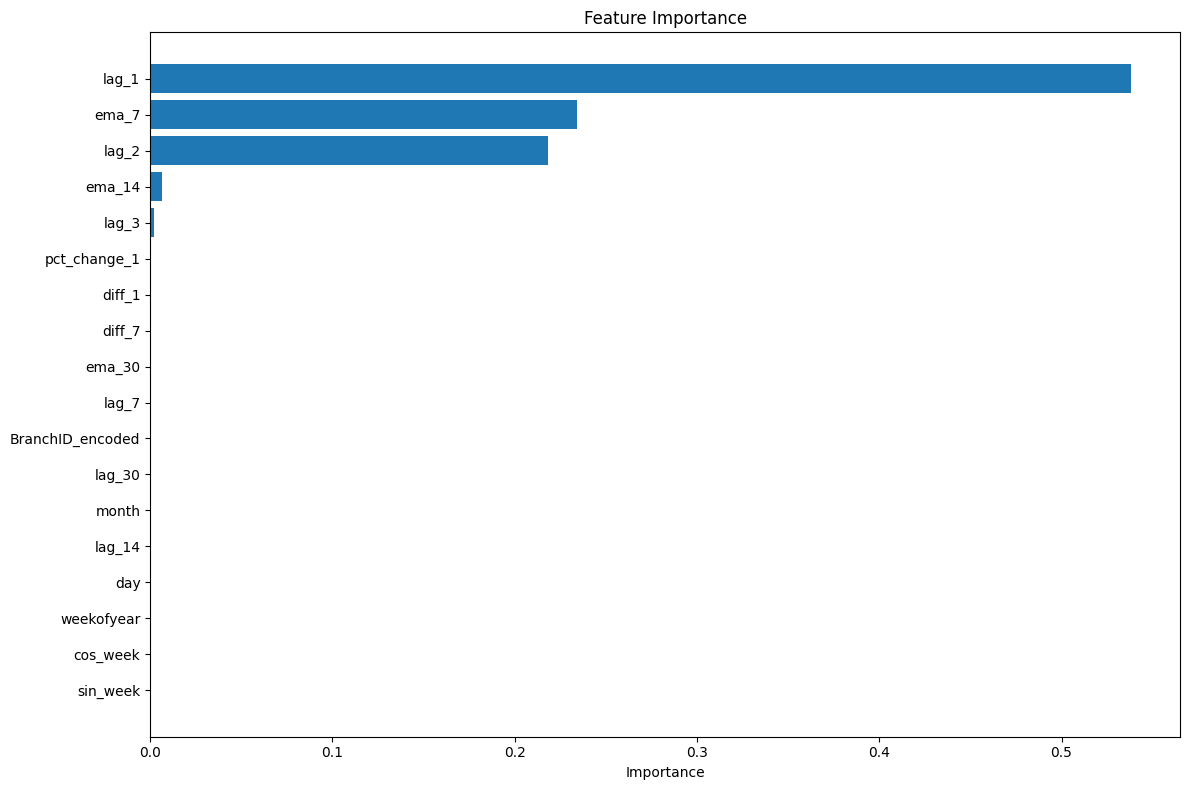

In [54]:
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(12, 8))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.gca().invert_yaxis()

plt.title('Feature Importance')

plt.xlabel('Importance')

plt.tight_layout()

plt.show()

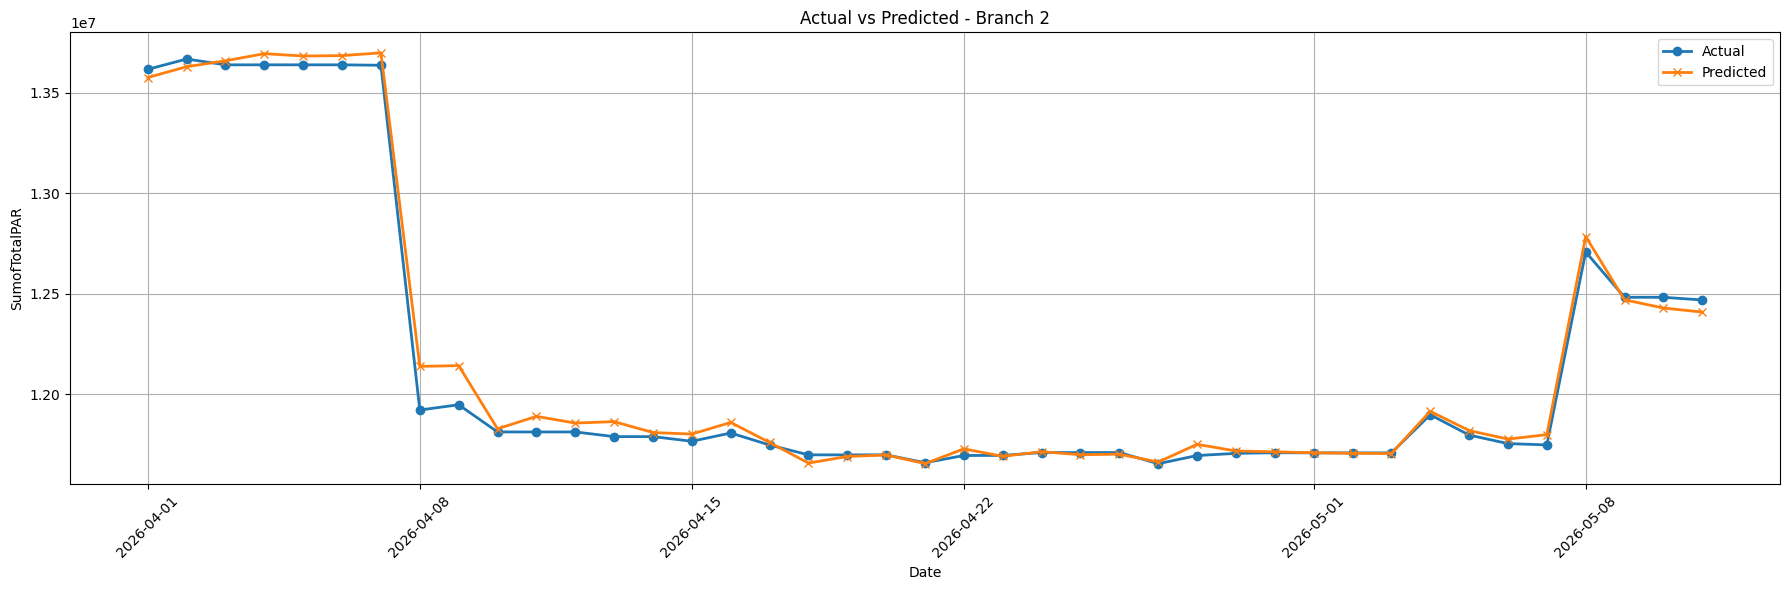

In [55]:
results_df = test_df[['Date', 'BranchID']].copy()
results_df['Actual'] = y_test.values
results_df['Predicted'] = preds
branch_id = 2
branch_df = results_df[
    results_df['BranchID'] == branch_id
].sort_values('Date')

plt.figure(figsize=(18,6))

plt.plot(
    branch_df['Date'],
    branch_df['Actual'],
    label='Actual',
    linewidth=2,
    marker='o'
)

plt.plot(
    branch_df['Date'],
    branch_df['Predicted'],
    label='Predicted',
    linewidth=2,
    marker='x'
)

plt.title(f'Actual vs Predicted - Branch {branch_id}')

plt.xlabel('Date')

plt.ylabel('SumofTotalPAR')

plt.legend()

plt.grid()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()